In [1]:

import os
import zipfile
import requests
import pandas as pd
import glob
import shutil

url = 'https://data.4tu.nl/file/a3094315-d0d6-4326-8194-1536c709fa93/bc76839d-27b5-408a-b851-bc8f948ecdbd'
zip_path = 'data.zip'
extract_dir = 'spotify_data'

# Check if dataset already exists to avoid re-downloading
if len(glob.glob("dataset-of-*.csv")) >= 6:
    print("Dataset already downloaded locally. Skipping download step.")
    zip_path = None
else:
    print("Attempting to download from 4TU.ResearchData...")
    try:
        response = requests.get(url, stream=True, timeout=30)
        response.raise_for_status()
        with open(zip_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print("Download from 4TU successful!")
    except Exception as e:
        print(f"4TU download failed: {e}. Falling back to Kaggle via kagglehub...")
        import kagglehub
        path = kagglehub.dataset_download("theoverman/the-spotify-hit-predictor-dataset")
        print("Kaggle download successful!")
        for item in os.listdir(path):
            src_file = os.path.join(path, item)
            dst_file = item
            if os.path.exists(dst_file):
                os.remove(dst_file)
            shutil.copy2(src_file, dst_file)
        zip_path = None


Dataset already downloaded locally. Skipping download step.


In [2]:
# Step 2: Unzip the files if downloaded from 4TU and list them
if zip_path and os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Extracted contents of ZIP to {extract_dir}:")
    files = os.listdir(extract_dir)
    print(files)
    csv_files = glob.glob(os.path.join(extract_dir, "*.csv"))
else:
    # Loaded from kaggle
    print("Files in Kaggle dataset directory:")
    csv_files = glob.glob("*.csv")
    print(csv_files)

Files in Kaggle dataset directory:
['dataset-of-00s.csv', 'dataset-of-10s.csv', 'dataset-of-60s.csv', 'dataset-of-70s.csv', 'dataset-of-80s.csv', 'dataset-of-90s.csv']


In [3]:
# Step 3: Load decade CSVs, add "decade" column, and combine them
dfs = []
for file_path in csv_files:
    filename = os.path.basename(file_path)
    # Infer decade name from filename (e.g., dataset-of-00s.csv -> '00s')
    decade = "Unknown"
    for d in ['60s', '70s', '80s', '90s', '00s', '10s']:
        if d in filename:
            decade = d
            break

    temp_df = pd.read_csv(file_path)
    temp_df['decade'] = decade
    dfs.append((decade, temp_df))
    print(f"Loaded {filename} for decade '{decade}' with {len(temp_df)} rows.")

# Combine into one main DataFrame
df = pd.concat([d[1] for d in dfs], ignore_index=True)

Loaded dataset-of-00s.csv for decade '00s' with 5872 rows.
Loaded dataset-of-10s.csv for decade '10s' with 6398 rows.
Loaded dataset-of-60s.csv for decade '60s' with 8642 rows.
Loaded dataset-of-70s.csv for decade '70s' with 7766 rows.
Loaded dataset-of-80s.csv for decade '80s' with 6908 rows.
Loaded dataset-of-90s.csv for decade '90s' with 5520 rows.


In [4]:
# Step 4: Print required statistics
total_rows, total_cols = df.shape
print(f"Total records (rows): {total_rows}")
print(f"Total columns: {total_cols}\n")

print("Number of rows in each decade file:")
for decade, temp_df in dfs:
    print(f"  - Decade {decade}: {len(temp_df)} rows")
print()

total_missing = df.isnull().sum().sum()
print(f"Total number of missing values: {total_missing}\n")

# 'uri' column is typically used as the unique ID
duplicates_uri = df.duplicated(subset=['uri']).sum()
print(f"Number of duplicate rows based on 'uri' column: {duplicates_uri}\n")

print("Target Column Class Distribution:")
counts = df['target'].value_counts()
percentages = df['target'].value_counts(normalize=True) * 100
for cls in counts.index:
    label = "Hit (1)" if cls == 1 else "Flop (0)"
    print(f"  - {label}: {counts[cls]} ({percentages[cls]:.2f}%)")
print()

print("Column Names and Data Types:")
print(df.dtypes)
print()

Total records (rows): 41106
Total columns: 20

Number of rows in each decade file:
  - Decade 00s: 5872 rows
  - Decade 10s: 6398 rows
  - Decade 60s: 8642 rows
  - Decade 70s: 7766 rows
  - Decade 80s: 6908 rows
  - Decade 90s: 5520 rows

Total number of missing values: 0

Number of duplicate rows based on 'uri' column: 546

Target Column Class Distribution:
  - Hit (1): 20553 (50.00%)
  - Flop (0): 20553 (50.00%)

Column Names and Data Types:
track                   str
artist                  str
uri                     str
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
time_signature        int64
chorus_hit          float64
sections              int64
target                int64
decade             

In [5]:
# Step 5: One-line summary
print(f"Total records: {total_rows}, Total columns: {total_cols}")

Total records: 41106, Total columns: 20


## Part B: Exploratory Data Analysis (EDA)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Data Cleaning
print('Original shape:', df.shape)
df_clean = df.drop_duplicates(subset=['uri']).copy()
print('Shape after dropping duplicates:', df_clean.shape)
df_clean = df_clean.drop(columns=['track', 'artist', 'uri'])

# One-hot encode key, time_signature, decade
cat_features = ['key', 'mode', 'time_signature', 'decade']
num_features = [c for c in df_clean.columns if c not in cat_features and c != 'target']

df_encoded = pd.get_dummies(df_clean, columns=['key', 'time_signature', 'decade'], drop_first=True)
df_encoded = df_encoded.astype({col: 'int' for col in df_encoded.select_dtypes('bool').columns})


Original shape: (41106, 20)
Shape after dropping duplicates: (40560, 20)


In [7]:
# 2. Multicollinearity (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_num = df_clean[num_features]
X_vif = add_constant(X_num)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
vif_data = vif_data[vif_data['Feature'] != 'const'].reset_index(drop=True)

print('Variance Inflation Factors:')
display(vif_data)
high_vif = vif_data[vif_data['VIF'] > 5]
if len(high_vif) > 0:
    print(f'\nFeatures with VIF > 5:\n{high_vif}')
else:
    print('\nNo numerical features with VIF > 5.')


Variance Inflation Factors:


,Feature,VIF
0,danceability,1.781335
1,energy,4.277003
2,loudness,2.969014
3,speechiness,1.092864
4,acousticness,2.256313
5,instrumentalness,1.305008
6,liveness,1.088374
7,valence,1.816794
8,tempo,1.110703
9,duration_ms,5.888196



Features with VIF > 5:
        Feature       VIF
9   duration_ms  5.888196
11     sections  5.760858


--- Statistical Tests vs Target ---
Mann-Whitney U for danceability: p-value=0.00e+00
Mann-Whitney U for energy: p-value=1.02e-193
Mann-Whitney U for loudness: p-value=0.00e+00
Mann-Whitney U for speechiness: p-value=5.77e-151
Mann-Whitney U for acousticness: p-value=6.09e-248
Mann-Whitney U for instrumentalness: p-value=0.00e+00
Mann-Whitney U for liveness: p-value=3.23e-28
Mann-Whitney U for valence: p-value=0.00e+00
Mann-Whitney U for tempo: p-value=1.16e-14
Mann-Whitney U for duration_ms: p-value=2.37e-04
Mann-Whitney U for chorus_hit: p-value=2.29e-10
Mann-Whitney U for sections: p-value=6.20e-05
Chi-Square for key: p-value=2.49e-26
Chi-Square for mode: p-value=5.79e-58
Chi-Square for time_signature: p-value=8.98e-209
Chi-Square for decade: p-value=4.76e-01


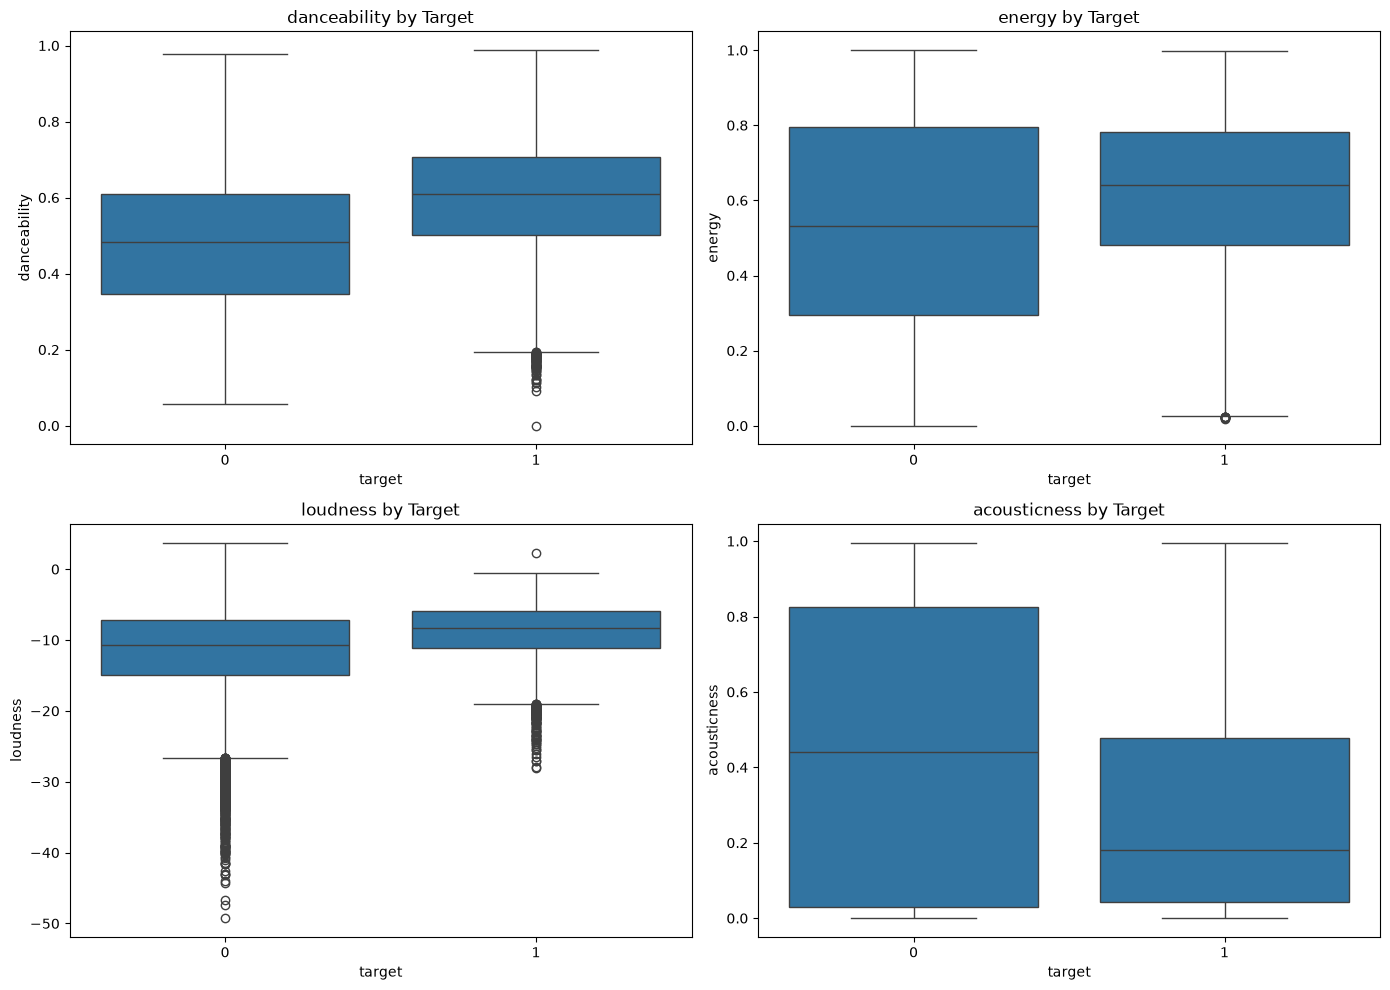

In [8]:
# 3. Relationships with Target & Statistical Tests
print('--- Statistical Tests vs Target ---')
for feature in num_features:
    group0 = df_clean[df_clean['target'] == 0][feature]
    group1 = df_clean[df_clean['target'] == 1][feature]
    stat, p = stats.mannwhitneyu(group0, group1, alternative='two-sided')
    print(f'Mann-Whitney U for {feature}: p-value={p:.2e}')

for feature in cat_features:
    contingency = pd.crosstab(df_clean[feature], df_clean['target'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    print(f'Chi-Square for {feature}: p-value={p:.2e}')

# Boxplots
key_features = ['danceability', 'energy', 'loudness', 'acousticness']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, feature in enumerate(key_features):
    row = i // 2
    col = i % 2
    sns.boxplot(data=df_clean, x='target', y=feature, ax=axes[row, col])
    axes[row, col].set_title(f'{feature} by Target')
plt.tight_layout()
plt.show()


In [9]:
# 4. Outliers
outlier_counts = {}
for col in num_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_clean[(df_clean[col] < (Q1 - 1.5 * IQR)) | (df_clean[col] > (Q3 + 1.5 * IQR))]
    outlier_counts[col] = len(outliers)

outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=['Feature', 'Outlier Count'])
display(outlier_df)
print('Outliers will be retained as tree-based models are robust to them and they represent valid variations.')


,Feature,Outlier Count
0,danceability,1
1,energy,0
2,loudness,1329
3,speechiness,4959
4,acousticness,0
5,instrumentalness,8778
6,liveness,2662
7,valence,0
8,tempo,424
9,duration_ms,1968


Outliers will be retained as tree-based models are robust to them and they represent valid variations.


In [10]:
# 5. Important predictors identified
from sklearn.metrics import roc_auc_score
print('--- Individual Feature AUCs ---')
auc_scores = {}
for col in num_features:
    auc = roc_auc_score(df_clean['target'], df_clean[col])
    auc_scores[col] = max(auc, 1 - auc)

auc_df = pd.DataFrame(list(auc_scores.items()), columns=['Feature', 'AUC (Directionless)']).sort_values('AUC (Directionless)', ascending=False)
display(auc_df)
print("Based on individual AUC scores, 'danceability' and 'energy' have high predictive power.\n")

from sklearn.model_selection import train_test_split
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Training set: {X_train.shape}, Test set: {X_test.shape}')


--- Individual Feature AUCs ---


,Feature,AUC (Directionless)
5,instrumentalness,0.739862
0,danceability,0.695898
2,loudness,0.642372
7,valence,0.639556
4,acousticness,0.596418
1,energy,0.585123
3,speechiness,0.575031
6,liveness,0.531580
8,tempo,0.522136
10,chorus_hit,0.518178


Based on individual AUC scores, 'danceability' and 'energy' have high predictive power.

Training set: (32448, 33), Test set: (8112, 33)


## Part C: Traditional Statistical Model (Logistic Regression)

In [11]:
from sklearn.preprocessing import StandardScaler
from statsmodels.discrete.discrete_model import Logit
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from sklearn.metrics import accuracy_score, f1_score, classification_report, log_loss

# 7. Standardize predictors
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 6. Full logistic regression using statsmodels
X_train_sm = add_constant(X_train_scaled)
X_test_sm = add_constant(X_test_scaled)
log_reg_sm = Logit(y_train.values, X_train_sm).fit(disp=0)

p_values = log_reg_sm.pvalues.drop('const')
top_3_p = p_values.nsmallest(3)
print('Top 3 Statistically Significant Predictors (by p-value):')
for feature, p_val in top_3_p.items():
    coef = log_reg_sm.params[feature]
    odds_ratio = np.exp(coef)
    direction = 'Positive' if coef > 0 else 'Negative'
    print(f'- {feature}: p-value = {p_val:.2e}, Direction = {direction}, Odds Ratio = {odds_ratio:.4f}')


Top 3 Statistically Significant Predictors (by p-value):
- instrumentalness: p-value = 0.00e+00, Direction = Negative, Odds Ratio = 0.3606
- danceability: p-value = 3.19e-284, Direction = Positive, Odds Ratio = 2.0556
- acousticness: p-value = 5.11e-181, Direction = Negative, Odds Ratio = 0.5377


In [12]:
# 8. RFECV
print('\nPerforming RFECV to select features...')
lr_estimator = LogisticRegression(max_iter=2000, random_state=42)
rfecv = RFECV(estimator=lr_estimator, step=1, cv=3, scoring='accuracy', n_jobs=-1)
rfecv.fit(X_train_scaled, y_train)

selected_features = X_train_scaled.columns[rfecv.support_].tolist()
print(f'RFECV selected {rfecv.n_features_} features to maximize cross-validated accuracy.')

# Refit reduced model
X_train_reduced_sm = add_constant(X_train_scaled[selected_features])
X_test_reduced_sm = add_constant(X_test_scaled[selected_features])
reduced_log_reg_sm = Logit(y_train.values, X_train_reduced_sm).fit(disp=0)

# 9. Pseudo-R2
print(f"\nReduced Model McFadden's Pseudo-R²: {reduced_log_reg_sm.prsquared:.4f}")

preds_prob_lr = reduced_log_reg_sm.predict(X_test_reduced_sm)
preds_class_lr = (preds_prob_lr > 0.5).astype(int)
acc_lr = accuracy_score(y_test, preds_class_lr)
auc_lr = roc_auc_score(y_test, preds_prob_lr)
f1_lr = f1_score(y_test, preds_class_lr)



Performing RFECV to select features...


RFECV selected 28 features to maximize cross-validated accuracy.

Reduced Model McFadden's Pseudo-R²: 0.2551


## Part D: Machine Learning Models
Note: StandardScaler is not required for tree-based models (Random Forest, Gradient Boosting) as they are scale-invariant. It is applied here purely for pipeline consistency with the logistic regression model.

In [13]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# 10. Random Forest Tuning
rf = RandomForestClassifier(random_state=42)
rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, 30, None], 'min_samples_split': [2, 5]}
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_
print(f'Best RF Params: {rf_grid.best_params_}')
print(f'Best RF CV Score: {rf_grid.best_score_:.4f}')

preds_prob_rf = best_rf.predict_proba(X_test_scaled)[:, 1]
preds_class_rf = best_rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, preds_class_rf)
auc_rf = roc_auc_score(y_test, preds_prob_rf)
f1_rf = f1_score(y_test, preds_class_rf)


Best RF Params: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV Score: 0.8002


In [14]:
# Gradient Boosting Tuning
gb = GradientBoostingClassifier(random_state=42)
gb_params = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3, 5, 7]}
gb_grid = GridSearchCV(gb, gb_params, cv=3, scoring='accuracy', n_jobs=-1)
gb_grid.fit(X_train_scaled, y_train)
best_gb = gb_grid.best_estimator_
print(f'Best GB Params: {gb_grid.best_params_}')
print(f'Best GB CV Score: {gb_grid.best_score_:.4f}')

preds_prob_gb = best_gb.predict_proba(X_test_scaled)[:, 1]
preds_class_gb = best_gb.predict(X_test_scaled)
acc_gb = accuracy_score(y_test, preds_class_gb)
auc_gb = roc_auc_score(y_test, preds_prob_gb)
f1_gb = f1_score(y_test, preds_class_gb)


Best GB Params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200}
Best GB CV Score: 0.8043


## Part E: Discussion (Threshold Tuning)

,Model,Accuracy,ROC-AUC,F1-Score
0,Logistic Regression,0.740015,0.815313,0.755194
1,Random Forest,0.803131,0.882903,0.810445
2,Gradient Boosting,0.814596,0.890842,0.821165


The best-performing model based on evidence is Gradient Boosting.

--- Gradient Boosting Threshold Tuning ---
Metrics at Default Threshold (0.5):
  Accuracy:  0.8146
  Precision: 0.7837
  Recall:    0.8624
  F1-Score:  0.8212

Metrics at Youden's J Optimal Threshold (0.5291):
  Accuracy:  0.8153
  Precision: 0.7932
  Recall:    0.8467
  F1-Score:  0.8190


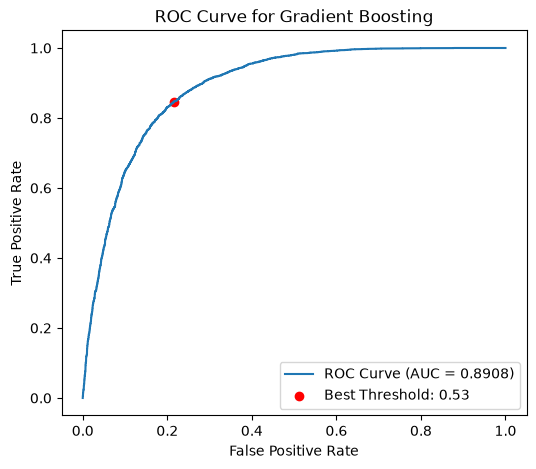

In [15]:
from sklearn.metrics import precision_score, recall_score, roc_curve

# 12. Comparison Table
metrics_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [acc_lr, acc_rf, acc_gb],
    'ROC-AUC': [auc_lr, auc_rf, auc_gb],
    'F1-Score': [f1_lr, f1_rf, f1_gb]
}
metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

best_model_name = metrics_df.loc[metrics_df['ROC-AUC'].idxmax(), 'Model']
print(f'The best-performing model based on evidence is {best_model_name}.')

if best_model_name == 'Gradient Boosting':
    best_probs = preds_prob_gb
elif best_model_name == 'Random Forest':
    best_probs = preds_prob_rf
else:
    best_probs = preds_prob_lr

# 13. Threshold Tuning
fpr, tpr, thresholds = roc_curve(y_test, best_probs)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

custom_preds = (best_probs >= best_threshold).astype(int)
default_preds = (best_probs >= 0.5).astype(int)

print(f'\n--- {best_model_name} Threshold Tuning ---')
print(f'Metrics at Default Threshold (0.5):')
print(f'  Accuracy:  {accuracy_score(y_test, default_preds):.4f}')
print(f'  Precision: {precision_score(y_test, default_preds):.4f}')
print(f'  Recall:    {recall_score(y_test, default_preds):.4f}')
print(f'  F1-Score:  {f1_score(y_test, default_preds):.4f}')

print(f'\nMetrics at Youden\'s J Optimal Threshold ({best_threshold:.4f}):')
print(f'  Accuracy:  {accuracy_score(y_test, custom_preds):.4f}')
print(f'  Precision: {precision_score(y_test, custom_preds):.4f}')
print(f'  Recall:    {recall_score(y_test, custom_preds):.4f}')
print(f'  F1-Score:  {f1_score(y_test, custom_preds):.4f}')

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, best_probs):.4f})')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label=f'Best Threshold: {best_threshold:.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for {best_model_name}')
plt.legend()
plt.show()
